### PI NADYA PUTRI NUR ALETTA (51423061)
### DETEKSI PENYAKIT DAUN MENTIMUN MENGGUNAKAN MODEL YOLO26m

#### BAGIAN 1: Verifikasi GPU dan Install Dependencies

In [1]:
# 1. Cek apakah GPU NVIDIA sudah aktif
!nvidia-smi

Sun Jun 28 14:15:16 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# 2. Install library Ultralytics untuk eksekusi YOLO dan Roboflow untuk mengambil data
!pip install ultralytics roboflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 86.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 133.1 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.18
    Uninstalling idna-3.18:
      Successfully uninstalled idna-3.18


#### BAGIAN 2: Mengunduh Dataset dari Roboflow

In [3]:
from roboflow import Roboflow

# Snippet atau API kode dari Roboflow
from roboflow import Roboflow
rf = Roboflow(api_key="Zm4bvMlEwsmRWr0VU3O6")
project = rf.workspace("aletta-workspace").project("pi_cucumber_leaf_disease-3")
version = project.version(1)
dataset = version.download("yolo26")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to pi_cucumber_leaf_disease-3-1 in yolo26:: 100%|██████████| 2315/2315 [00:00<00:00, 7063.01it/s]


#### BAGIAN 3: Menghubungkan Google Colab dengan Drive untuk Menyimpan Model Terbaik Saat Training

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#### BAGIAN 4: Inisialisasi Arsitektur dan Mulai Training YOLO26m (run3_default)

In [5]:
import os
from ultralytics import YOLO

# 1. Inisialisasi model YOLO26m
model = YOLO("yolo26m.pt")

# 2. Folder penyimpanan hasil training
save_directory = "/content/drive/MyDrive/PI (PENULISAN ILMIAH SEMESTER 6) 2026/FIX TANPA HYPERPARAMETER-DEFAULT YOLO26"
os.makedirs(save_directory, exist_ok=True)

# 3. Training dengan konfigurasi default YOLO26m
results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=200,
    imgsz=640,
    batch=16,
    device=0,
    project=save_directory,
    name="run3_default"
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.81 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/pi_cucumber_leaf_disease-3-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv

#### BAGIAN 5: Evaluasi Performa Model (Visualisasi Metrik) Dengan YOLO26m

--- MENAMPILKAN HASIL EVALUASI MODEL ---

[1] Confusion Matrix:


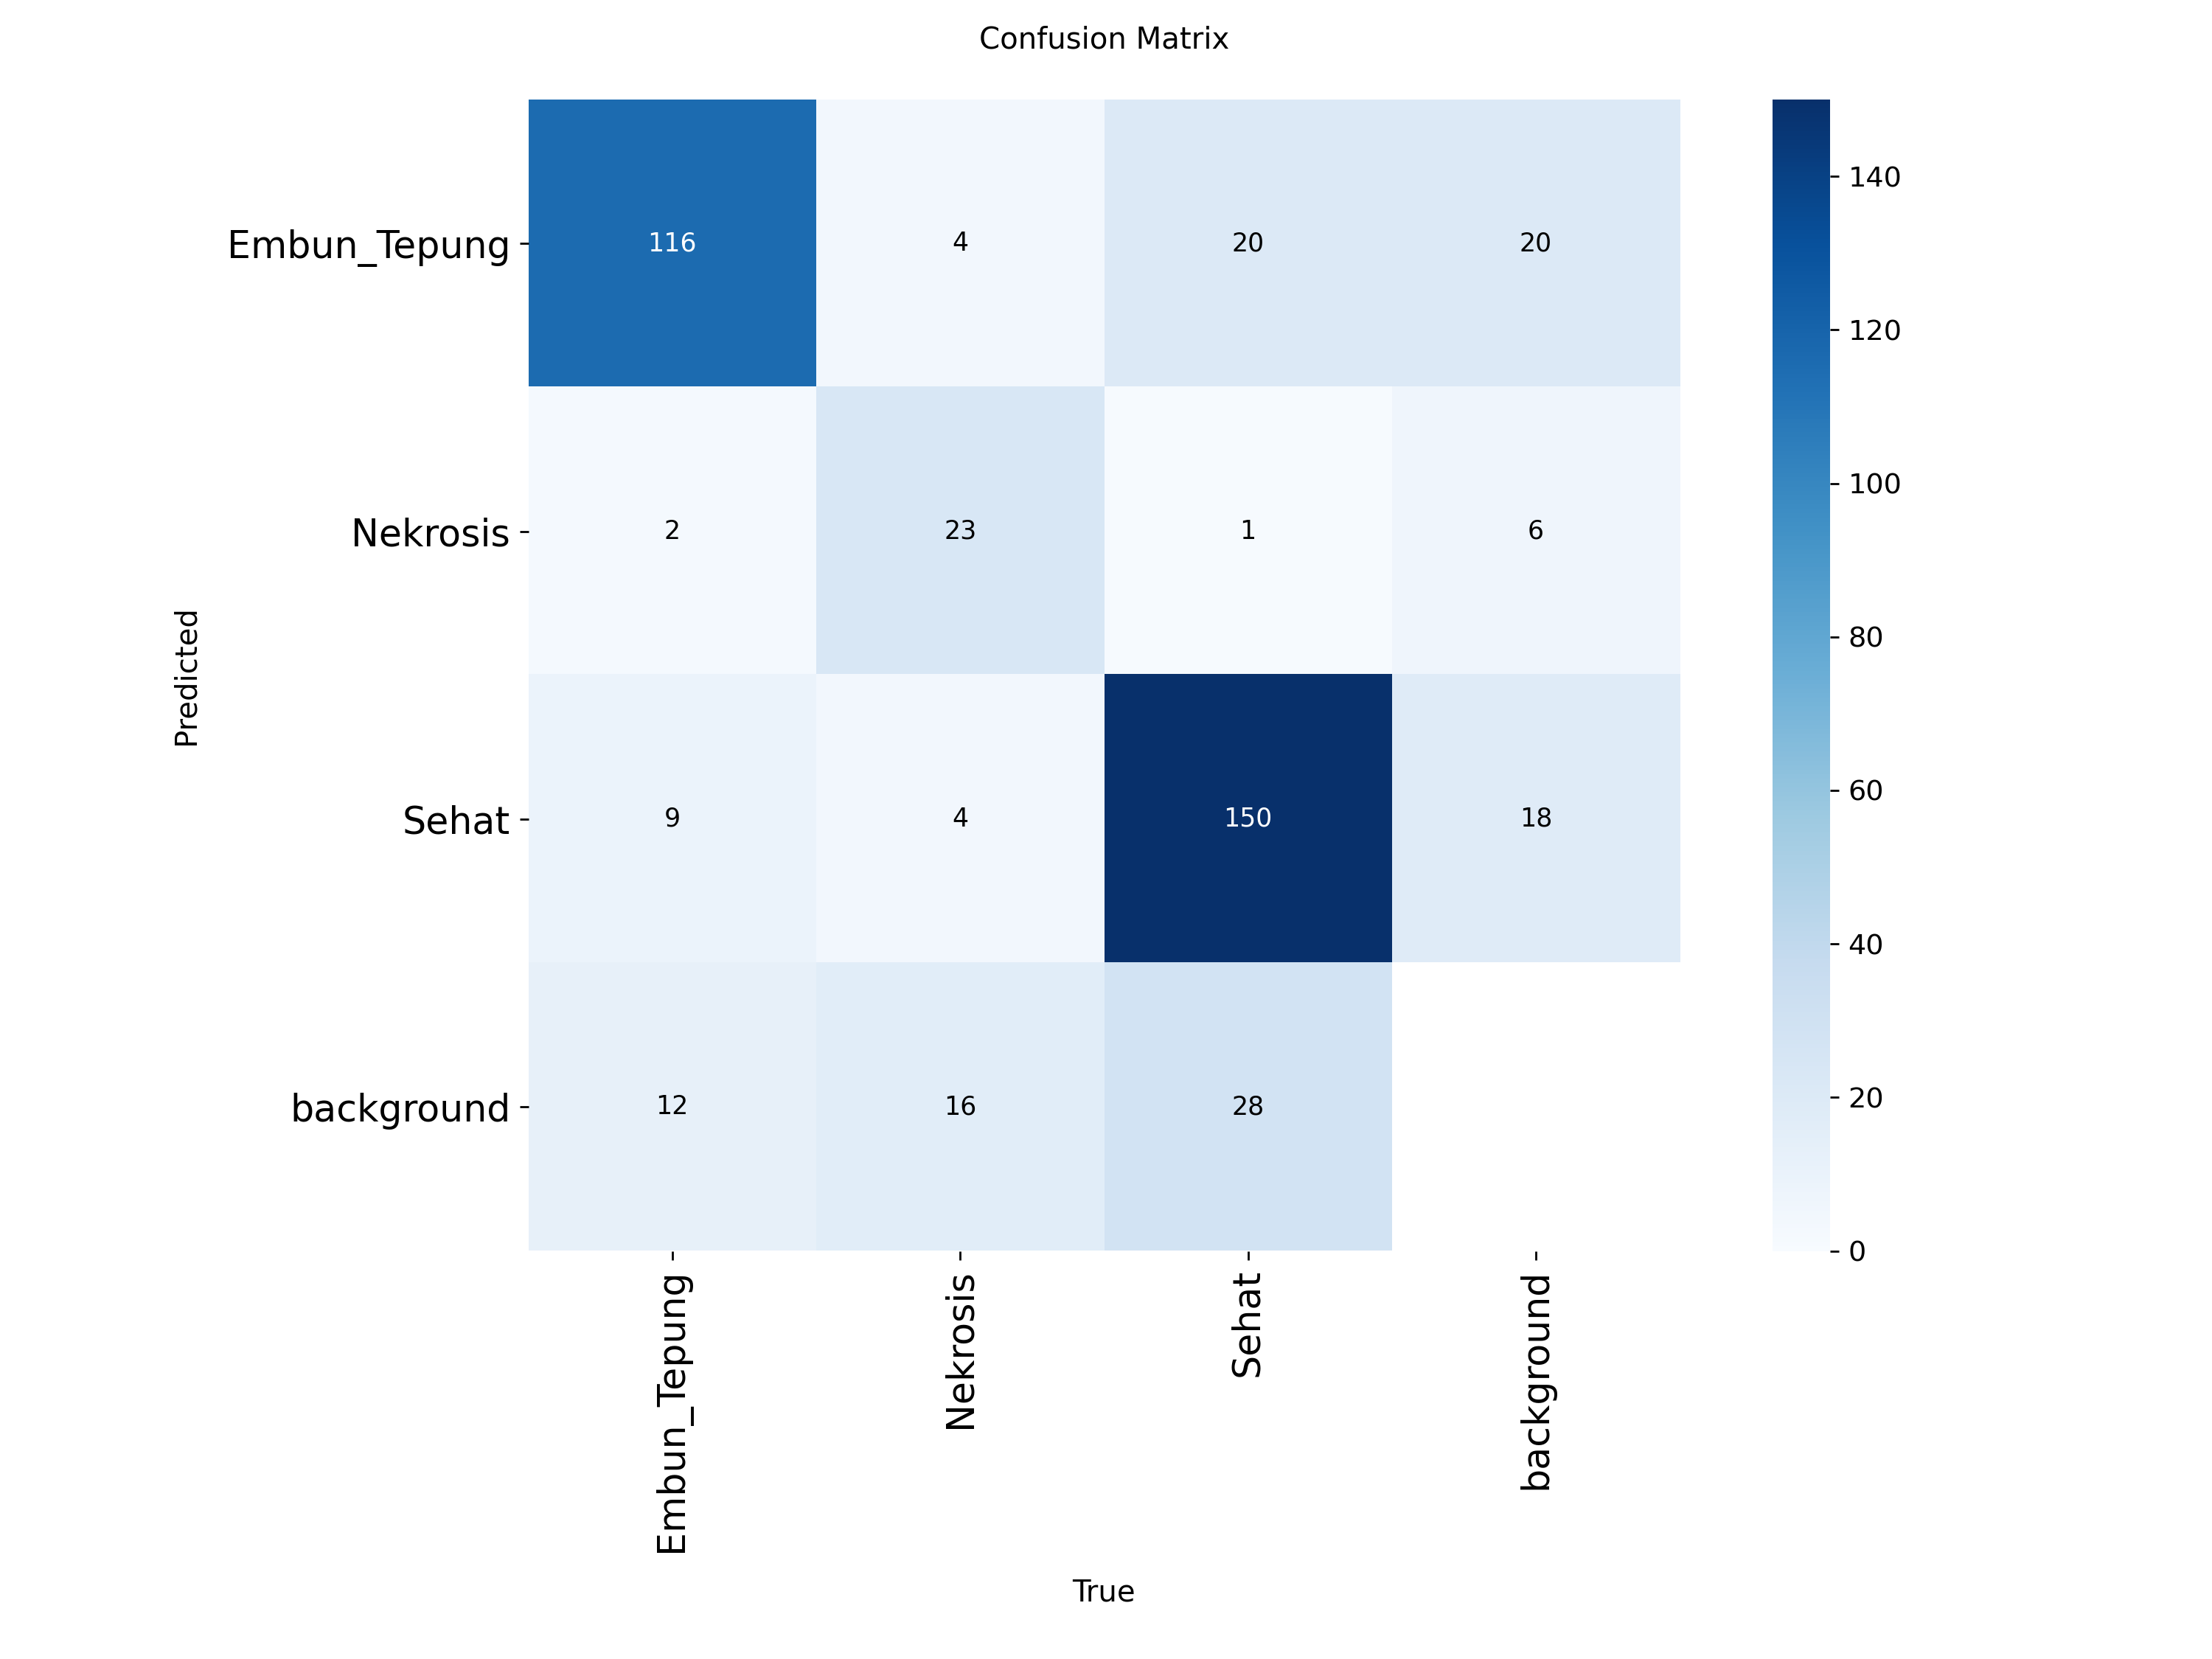


[2] Grafik Perkembangan Training (Loss & mAP):


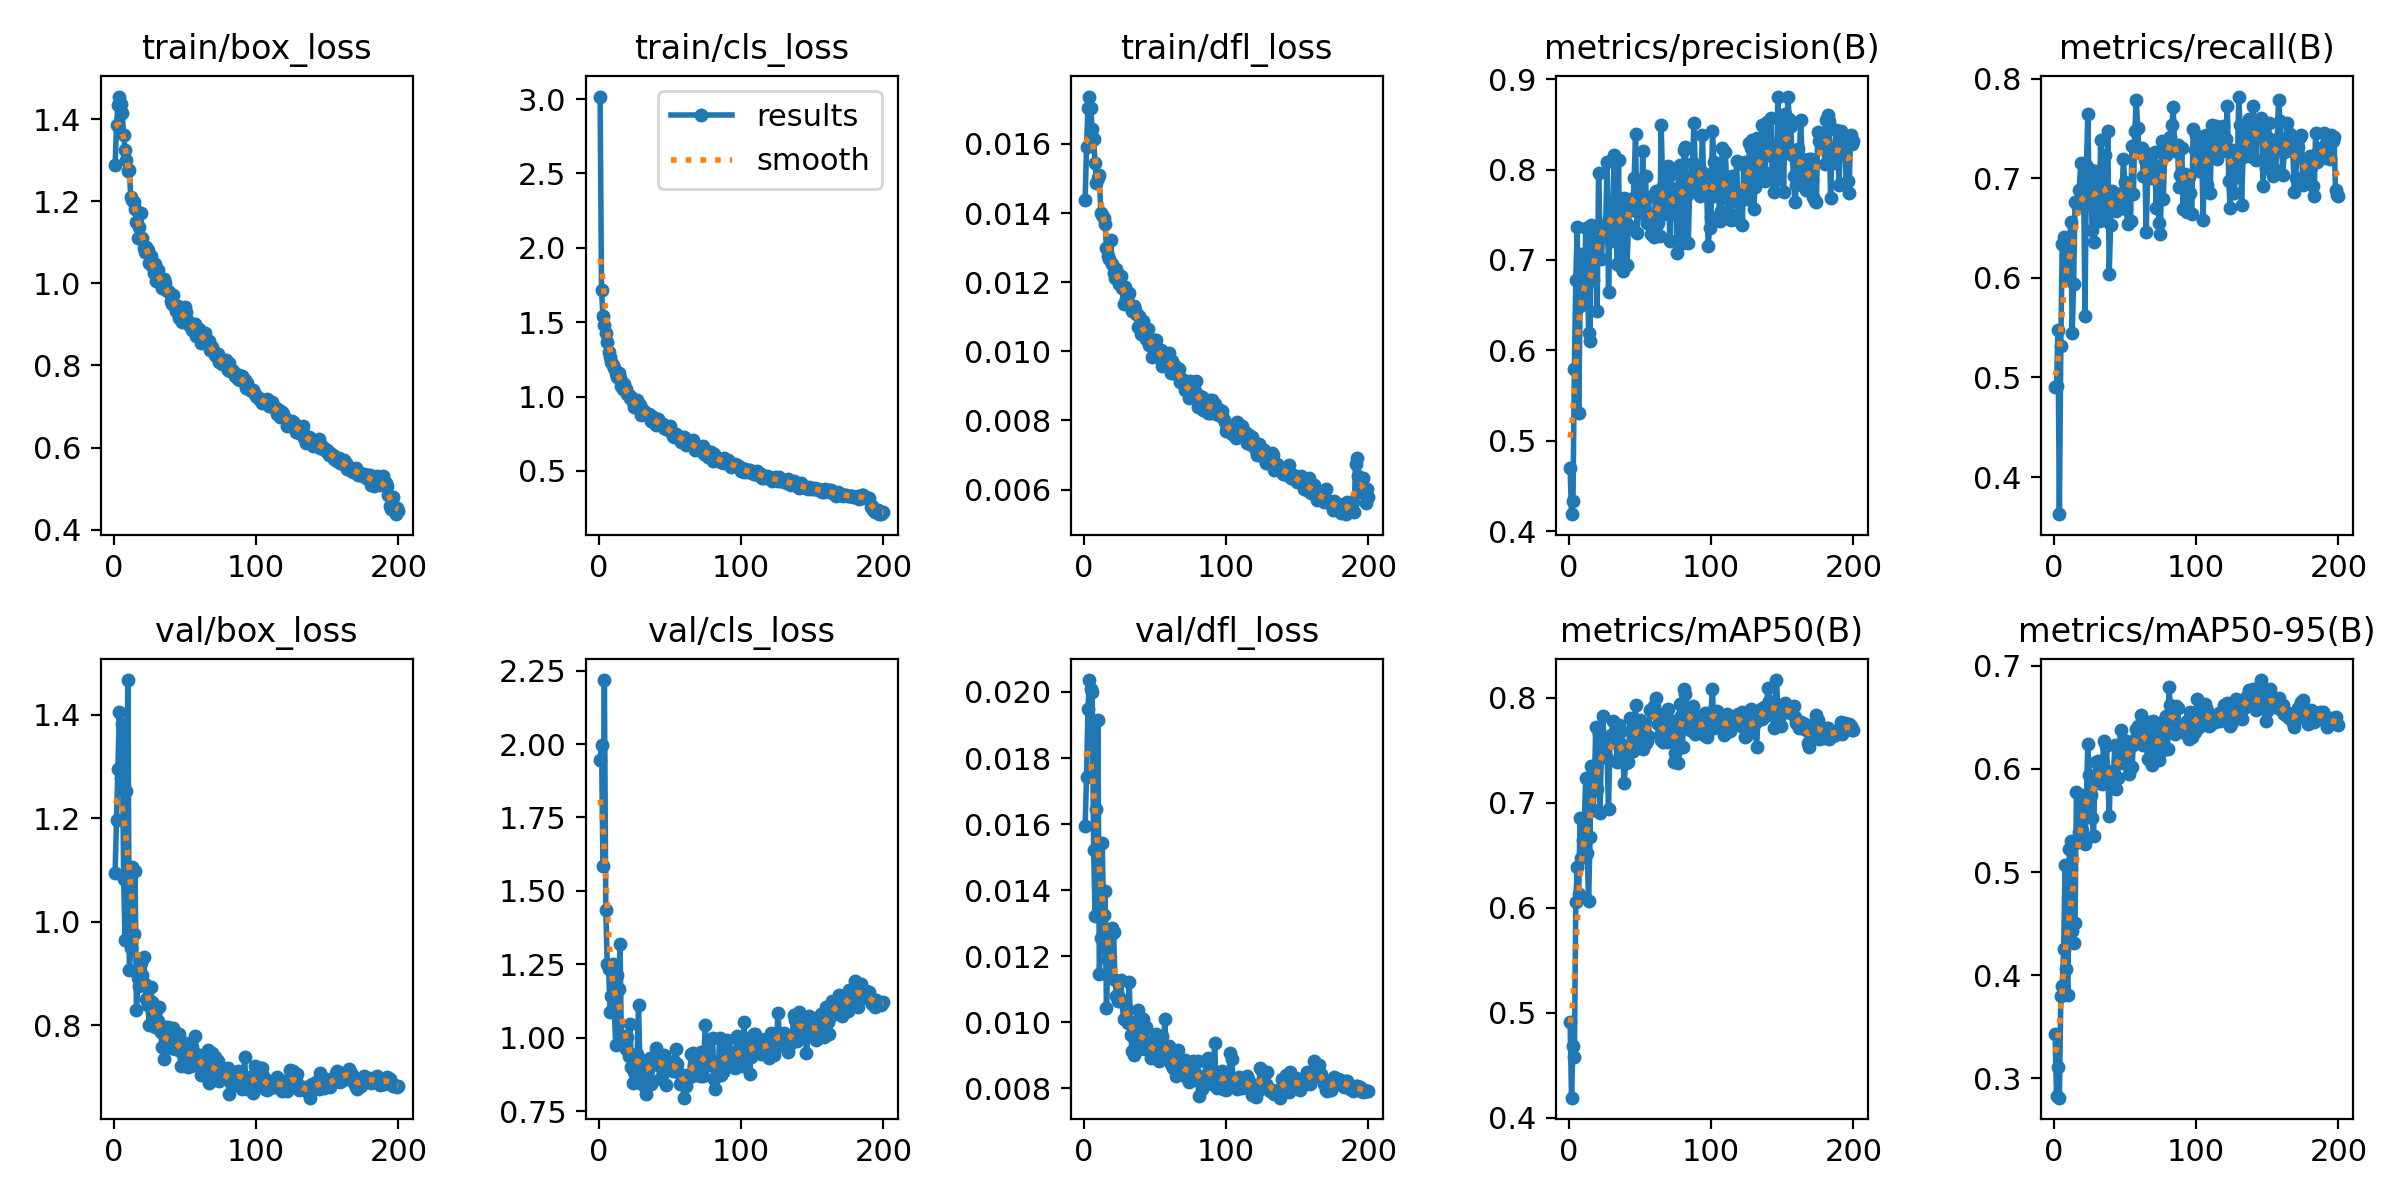

In [6]:
import os
from IPython.display import display, Image

# Jalur folder hasil training di Google Drive
run_dir = '/content/drive/MyDrive/PI (PENULISAN ILMIAH SEMESTER 6) 2026/FIX TANPA HYPERPARAMETER-DEFAULT YOLO26/run3_default'

print("--- MENAMPILKAN HASIL EVALUASI MODEL ---")

# 1. Menampilkan Confusion Matrix (Melihat akurasi deteksi per kelas penyakit)
confusion_matrix_path = os.path.join(run_dir, 'confusion_matrix.png')
if os.path.exists(confusion_matrix_path):
    print("\n[1] Confusion Matrix:")
    display(Image(filename=confusion_matrix_path, width=600))

# 2. Menampilkan Grafik Progress Results (Melihat penurunan Loss dan kenaikan mAP per Epoch)
results_plot_path = os.path.join(run_dir, 'results.png')
if os.path.exists(results_plot_path):
    print("\n[2] Grafik Perkembangan Training (Loss & mAP):")
    display(Image(filename=results_plot_path, width=800))

#### BAGIAN 6: Uji Coba Deteksi (Inference) Dengan Grid 2×5 Dengan YOLO26m

--- MENJALANKAN DETEKSI GRID PADA 10 GAMBAR INFERENCE ---


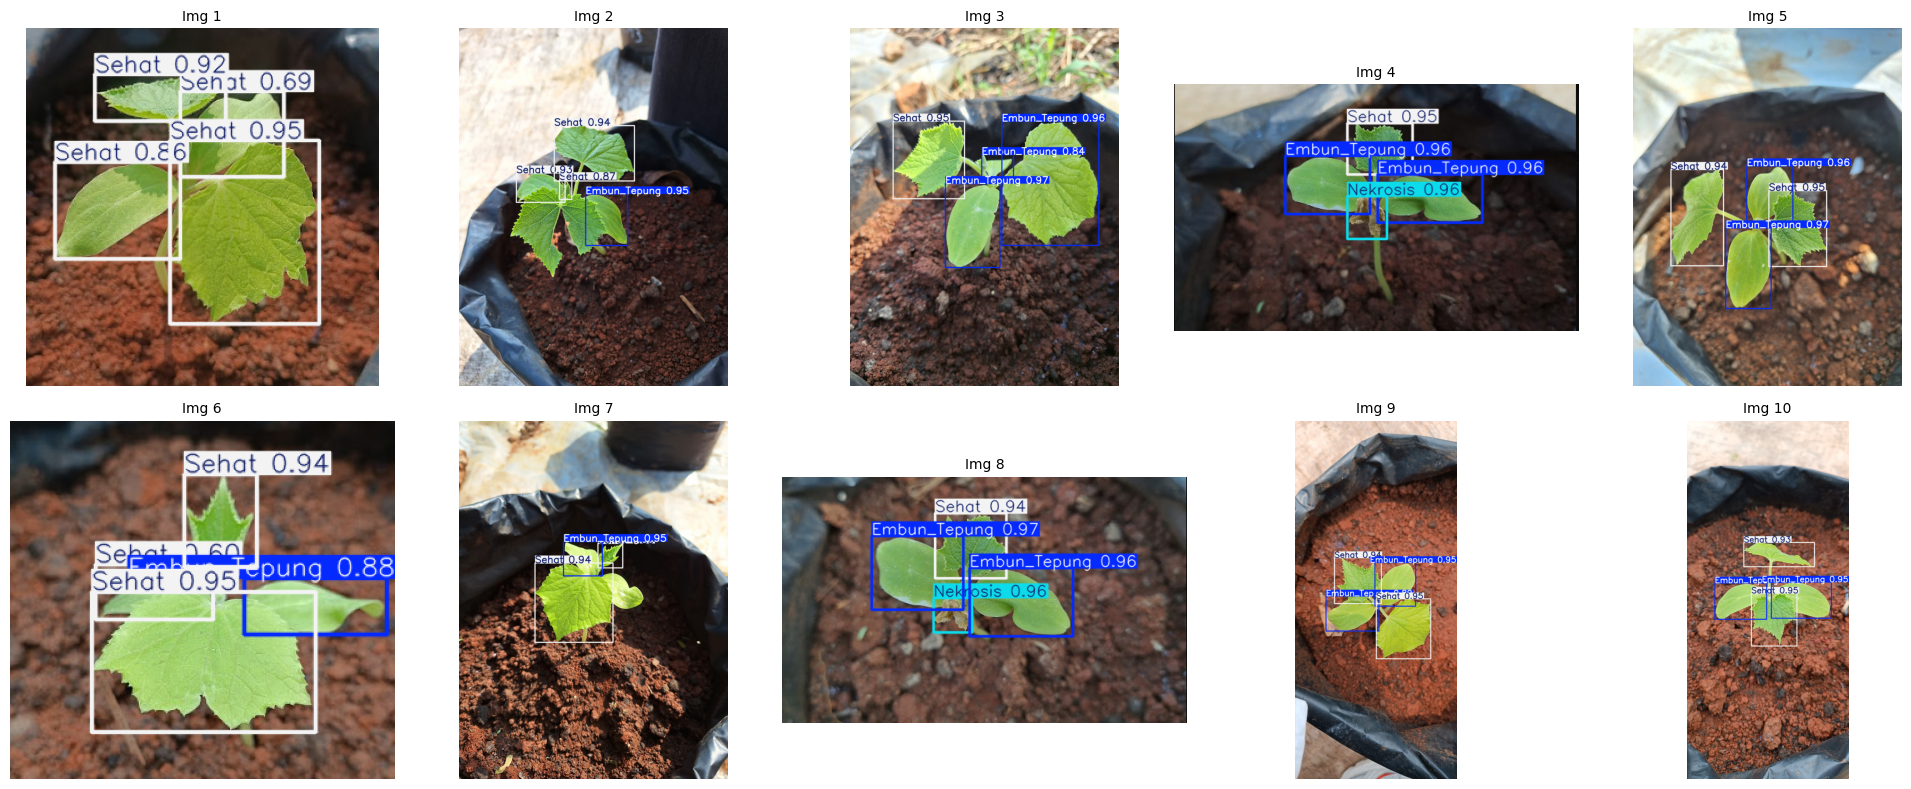

In [7]:
import glob
import os
import matplotlib.pyplot as plt
import cv2
from ultralytics import YOLO


# 1. Muat model yang tersimpan di GDrive
best_model_path = '/content/drive/MyDrive/PI (PENULISAN ILMIAH SEMESTER 6) 2026/FIX TANPA HYPERPARAMETER-DEFAULT YOLO26/run3_default/weights/best.pt'
model_best = YOLO(best_model_path)

# 3. Ambil seluruh sampel gambar dari folder DATA INFERENCE di GDrive
inference_folder_path = '/content/drive/MyDrive/PI (PENULISAN ILMIAH SEMESTER 6) 2026/DATA INFERENCE/*.jpg'
test_images = glob.glob(inference_folder_path)

print(f"--- MENJALANKAN DETEKSI GRID PADA {len(test_images)} GAMBAR INFERENCE ---")

# 4. Setup Grid Plot disesuaikan untuk 10 gambar (2 baris x 5 kolom)
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, img_path in enumerate(test_images):
    # Prediksi
    results = model_best.predict(source=img_path, conf=0.50, verbose=False)

    # Ambil hasil plot (gambar yang sudah ada bounding box)
    res_plotted = results[0].plot()

    # Konversi BGR ke RGB untuk matplotlib
    res_plotted = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)

    # Tampilkan di grid
    axes[i].imshow(res_plotted)
    axes[i].axis('off')
    axes[i].set_title(f"Img {i+1}", fontsize=10)

# Menghapus sumbu koordinat jika ada sisa grid ax yang kosong
for j in range(len(test_images), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()